<a href="https://colab.research.google.com/github/veerakumar17/veera-codeboosters-2026/blob/main/day2/day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")
print(f"pandas version:{pd.__version__}")
print(f"SQLite version:{sqlite3.version}")


All libraries imported successfully
pandas version:2.2.2
SQLite version:2.6.0


In [24]:
df = pd.read_csv('student_performance.csv')

print(f"Dataset Loaded: {df.shape[0]} students, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")

Dataset Loaded: 30 students, 13 columns
Columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


In [25]:
conn = sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students',
     conn,
     if_exists='replace',
     index=False
)
cursor.execute('SELECT count(*) from students')
count=cursor.fetchone()[0]
print(f"Database 'college.db' create successfully")
print(f"Table 'students' has {count} rows")
cursor.close()
conn.close()

Database 'college.db' create successfully
Table 'students' has 30 rows


In [26]:
def run_query(query, title):
    conn = sqlite3.connect('college.db')
    df_result = pd.read_sql_query(query, conn)
    conn.close()
    print(title)
    display(df_result)
    return df_result

In [27]:
query1="""
select student_id,name,department,math_score,attendance_percentage from students limit 10
"""
result=run_query(query1,"Query1: first 10 students")

Query1: first 10 students


,student_id,name,department,math_score,attendance_percentage
0,1001,Aarav Sharma,Computer Science,85,92
1,1002,Priya Patel,Computer Science,76,87
2,1003,Rohit Verma,Electronics,65,78
3,1004,Sneha Reddy,Mechanical,70,95
4,1005,Arjun Nair,Computer Science,92,90
5,1006,Meera Joshi,Electronics,58,72
6,1007,Kiran Kumar,Civil,73,85
7,1008,Divya Singh,Computer Science,88,96
8,1009,Rahul Mishra,Mechanical,62,68
9,1010,Ananya Das,Computer Science,95,98


In [28]:
query2="""
select student_id,name from students limit 5
"""
result=run_query(query2,"Query2: first 5 students")

Query2: first 5 students


,student_id,name
0,1001,Aarav Sharma
1,1002,Priya Patel
2,1003,Rohit Verma
3,1004,Sneha Reddy
4,1005,Arjun Nair


In [29]:
query3="""
select name,department,math_score from students order by math_score desc limit 5
"""
result=run_query(query3,"Query3: first 5 students ")

Query3: first 5 students 


,name,department,math_score
0,Ananya Das,Computer Science,95
1,Tanvi Mehta,Computer Science,93
2,Arjun Nair,Computer Science,92
3,Akanksha Yadav,Computer Science,91
4,Swati Kulkarni,Computer Science,90


In [30]:
query4="""
select name,math_score,programming_score,attendance_percentage from students where department='Computer Science' limit 10
"""
result=run_query(query4,"Query4: first 10 students from Computer Science")

Query4: first 10 students from Computer Science


,name,math_score,programming_score,attendance_percentage
0,Aarav Sharma,85,91,92
1,Priya Patel,76,79,87
2,Arjun Nair,92,95,90
3,Divya Singh,88,93,96
4,Ananya Das,95,97,98
5,Suresh Rao,83,88,88
6,Ajay Tiwari,71,76,75
7,Swati Kulkarni,90,92,94
8,Nisha Kapoor,79,83,89
9,Tanvi Mehta,93,96,97


In [31]:
query5="""
select distinct department from students
"""
result=run_query(query5,"Query5: Distinct ")

Query5: Distinct 


,department
0,Computer Science
1,Electronics
2,Mechanical
3,Civil


In [32]:
query6="""
select name,attendance_percentage
from students
where attendance_percentage between 80 AND 90
"""
result=run_query(query6,"Query6: students with attendance between 80 and 90")

Query6: students with attendance between 80 and 90


,name,attendance_percentage
0,Priya Patel,87
1,Arjun Nair,90
2,Kiran Kumar,85
3,Vikram Iyer,83
4,Pooja Gupta,80
5,Suresh Rao,88
6,Nisha Kapoor,89
7,Preeti Saxena,86
8,Rekha Nair,82
9,Gaurav Shukla,87


In [33]:
query7="""
select department,
    AVG(math_score) AS avg_math,
        COUNT(*) AS num_students
        FROM students
        GROUP BY department
        ORDER BY avg_math DESC;
        """
result=run_query(query7,"Query7: Average math score by department")

Query7: Average math score by department


,department,avg_math,num_students
0,Computer Science,85.615385,13
1,Mechanical,71.000000,6
2,Electronics,71.000000,6
3,Civil,63.400000,5


In [34]:
query8="""
 select
      department,
           COUNT(*)                                 AS num_students,
                ROUND(AVG(math_score), 2)                AS avg_math,
                     ROUND(AVG(science_score), 2)             AS avg_science,
                          ROUND(AVG(programming_score), 2)         AS avg_programming,
                               ROUND(AVG(attendance_percentage), 2)      AS avg_attendance
                               from students
                               group by department
                               order by avg_math desc
                               """
result=run_query(query8,"Query8: Average scores by department")

Query8: Average scores by department


,department,num_students,avg_math,avg_science,avg_programming,avg_attendance
0,Computer Science,13,85.62,84.46,89.23,90.69
1,Mechanical,6,71.00,76.50,49.33,83.50
2,Electronics,6,71.00,74.17,61.50,80.33
3,Civil,5,63.40,66.60,40.60,74.60


In [35]:
query9="""
 select
      department,
           COUNT(*)                                 AS num_students,
                ROUND(AVG(math_score), 2)                AS avg_math
                from students
                group by department
                having avg_math > 70
                order by avg_math desc
                """
result=run_query(query9,"Query9: Departments with average math score greater than 70")

Query9: Departments with average math score greater than 70


,department,num_students,avg_math
0,Computer Science,13,85.62
1,Mechanical,6,71.00
2,Electronics,6,71.00


In [36]:
query10="""
 select
      gender,
           COUNT(*) AS num_students,
                ROUND(AVG(math_score), 2) AS avg_math,
                     ROUND(AVG(programming_score), 2) AS avg_programming,
                          ROUND(AVG(attendance_percentage), 2) AS avg_attendance
                          from students
                          group by gender
                          order by gender
                          """
result=run_query(query10,"Query10: Gender-wise performance analysis with additional metrics")

Query10: Gender-wise performance analysis with additional metrics


,gender,num_students,avg_math,avg_programming,avg_attendance
0,Female,15,78.47,70.2,88.53
1,Male,15,73.67,65.0,80.47


Chart1: Average Math Scores by Department


,department,avg_math
0,Computer Science,85.62
1,Mechanical,71.00
2,Electronics,71.00
3,Civil,63.40


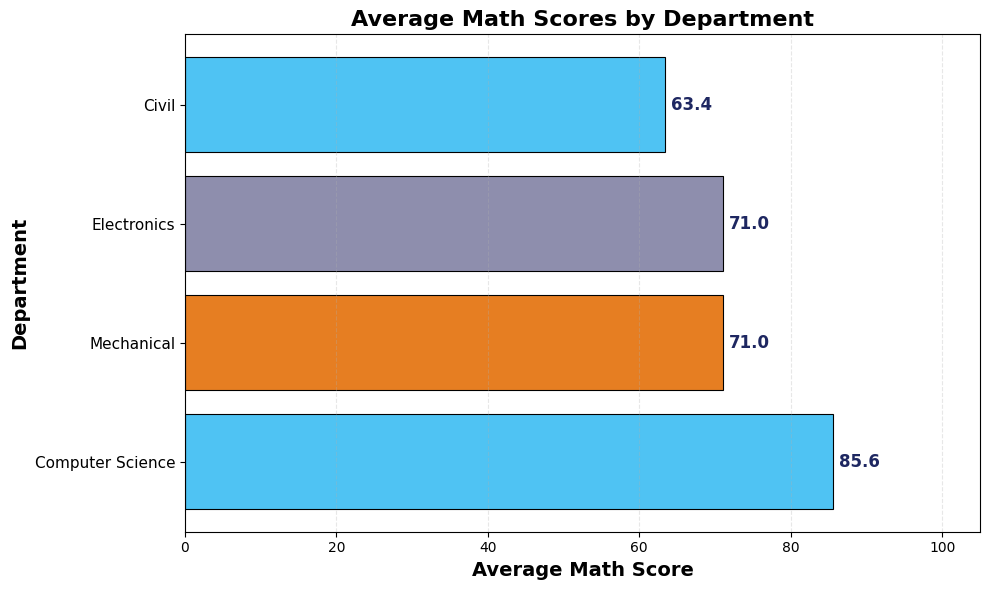

In [37]:
chart1_sql="""
select department,Round(AVG(math_score),2) as avg_math
from students
group by department
order by avg_math desc
"""
chart1_data=run_query(chart1_sql,"Chart1: Average Math Scores by Department")
fig,ax=plt.subplots(figsize=(10,6))
bar_colors=["#4FC3F3","#E67E22","#8E8EAD"]
bars=ax.barh(  # Changed to barh for horizontal bars
    chart1_data["department"],
    chart1_data["avg_math"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8)
for bar in bars:
    width=bar.get_width() # Get width for horizontal bars
    ax.text(
        width+0.8, # Position text horizontally
        bar.get_y()+bar.get_height()/2, # Center text vertically
        f'{width:.1f}',
        ha='left',va='center', # Align text for horizontal bars
        fontsize=12,fontweight='bold',
        color='#1E2761'
    )
ax.set_title('Average Math Scores by Department',fontsize=16,fontweight='bold')
ax.set_ylabel('Department',fontsize=14,fontweight='bold') # Swapped labels
ax.set_xlabel('Average Math Score',fontsize=14,fontweight='bold') # Swapped labels
ax.set_xlim(0,105) # Changed to xlim
ax.tick_params(axis='y',labelsize=11) # Changed to y axis ticks
ax.grid(axis='x',linestyle='--',alpha=0.3) # Changed to x axis grid
plt.tight_layout()
plt.show()

Chart2: Average Attendance by Gender


,gender,avg_attendance
0,Female,88.53
1,Male,80.47


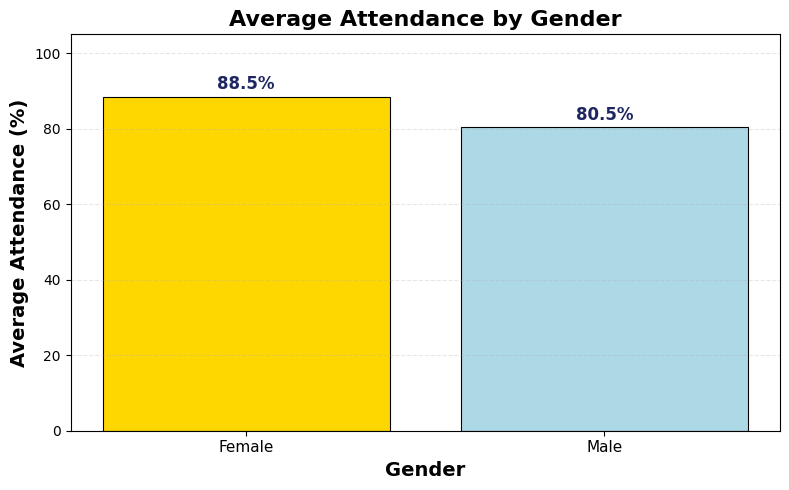

In [38]:
chart2_sql="""
select gender, ROUND(AVG(attendance_percentage), 2) as avg_attendance
from students
group by gender
order by avg_attendance desc
"""
chart2_data=run_query(chart2_sql,"Chart2: Average Attendance by Gender")

fig,ax=plt.subplots(figsize=(8, 5))
bar_colors=["#FFD700", "#ADD8E6"]
bars=ax.bar(
    chart2_data["gender"],
    chart2_data["avg_attendance"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8)

for bar in bars:
    height=bar.get_height()
    ax.text(
        bar.get_x()+bar.get_width()/2,
        height+0.8,
        f'{height:.1f}%',
        ha='center',va='bottom',
        fontsize=12,fontweight='bold',
        color='#1E2761'
    )

ax.set_title('Average Attendance by Gender',fontsize=16,fontweight='bold')
ax.set_xlabel('Gender',fontsize=14,fontweight='bold')
ax.set_ylabel('Average Attendance (%)',fontsize=14,fontweight='bold')
ax.set_ylim(0,105)
ax.tick_params(axis='x',labelsize=11)
ax.grid(axis='y',linestyle='--',alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
query11="""
select ROUND(AVG(programming_score), 2) as avg_programming_score_female
from students
where gender = 'Female'
"""
result=run_query(query11,"Query11: Average programming score for female students")

Query11: Average programming score for female students


,avg_programming_score_female
0,70.2


In [40]:
query12="""
select department, ROUND(AVG(attendance_percentage), 2) as avg_attendance
from students
group by department
having avg_attendance > 80
order by avg_attendance desc
"""
result=run_query(query12,"Query12: Departments with average attendance above 80%")

Query12: Departments with average attendance above 80%


,department,avg_attendance
0,Computer Science,90.69
1,Mechanical,83.50
2,Electronics,80.33


Chart1: Average Programming Scores by Department


,department,avg_programming
0,Computer Science,89.23
1,Electronics,61.50
2,Mechanical,49.33
3,Civil,40.60


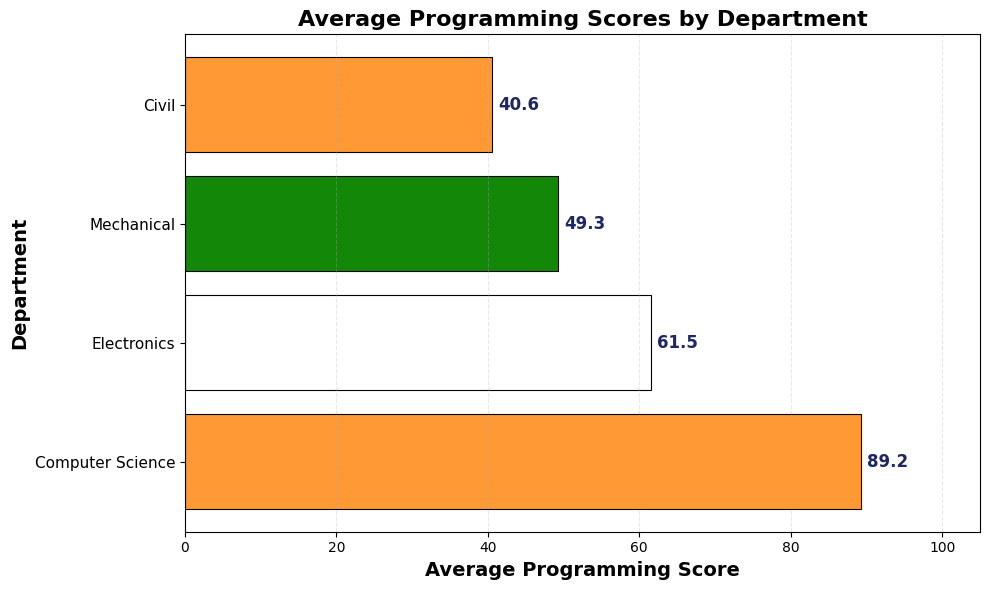

In [41]:
chart1_sql_new="""
select department,Round(AVG(programming_score),2) as avg_programming
from students
group by department
order by avg_programming desc
"""
chart1_data_new=run_query(chart1_sql_new,"Chart1: Average Programming Scores by Department")
fig,ax=plt.subplots(figsize=(10,6))
bar_colors=["#FF9933", "#FFFFFF", "#138808"] # Saffron, White, Green
bars=ax.barh(  # Changed to barh for horizontal bars
    chart1_data_new["department"],
    chart1_data_new["avg_programming"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8)
for bar in bars:
    width=bar.get_width() # Get width for horizontal bars
    ax.text(
        width+0.8, # Position text horizontally
        bar.get_y()+bar.get_height()/2, # Center text vertically
        f'{width:.1f}',
        ha='left',va='center', # Align text for horizontal bars
        fontsize=12,fontweight='bold',
        color='#1E2761'
    )
ax.set_title('Average Programming Scores by Department',fontsize=16,fontweight='bold')
ax.set_ylabel('Department',fontsize=14,fontweight='bold') # Swapped labels
ax.set_xlabel('Average Programming Score',fontsize=14,fontweight='bold') # Swapped labels
ax.set_xlim(0,105) # Changed to xlim
ax.tick_params(axis='y',labelsize=11) # Changed to y axis ticks
ax.grid(axis='x',linestyle='--',alpha=0.3) # Changed to x axis grid
plt.tight_layout()
plt.show()